# RF para datos fenotipicos y climaticos en PCA y heatmap

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import os
import sys

module_path = os.path.abspath(os.path.join("../../"))
if module_path not in sys.path:
    sys.path.append(module_path)

In [6]:
from machines.predictions.rf_prediction import RF_Prediction
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

## Carga de Archivo y preparar trainig and test

In [12]:
file_csv_original = {
    "phenotypic":           "../../../data/obregon_1516_1617/original/o_57_o_phenotypic.csv",
    "phenotypic_weather_d": "../../../data/obregon_1516_1617/original/o_57_o_phenotypic_weather_d.csv",
    "phenotypic_weather_w": "../../../data/obregon_1516_1617/original/o_57_o_phenotypic_weather_w.csv",
    "phenotypic_weather_f": "../../../data/obregon_1516_1617/original/o_57_o_phenotypic_weather_f.csv",
    "phenotypic_weather_m": "../../../data/obregon_1516_1617/original/o_57_o_phenotypic_weather_m.csv",
}

file_csv_heatmap = {
    "phenotypic":           "../../../data/obregon_1516_1617/correlation/o_57_c_phenotypic.csv",
    "phenotypic_weather_d": "../../../data/obregon_1516_1617/correlation/o_57_c_phenotypic_weather_d.csv",
    "phenotypic_weather_w": "../../../data/obregon_1516_1617/correlation/o_57_c_phenotypic_weather_w.csv",
    "phenotypic_weather_f": "../../../data/obregon_1516_1617/correlation/o_57_c_phenotypic_weather_f.csv",
    "phenotypic_weather_m": "../../../data/obregon_1516_1617/correlation/o_57_c_phenotypic_weather_m.csv",
}

## Original data

### Phenotypic

In [15]:
file_csv = file_csv_original["phenotypic"]
title_plot_true_predict = "RF original phenotypic"

In [16]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [17]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [18]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.64600519745614
R2 -> 0.8680812202887327
MAPE -> 0.03872169803677278


{'d2_absolute_error_score': 0.6832842506871926,
 'd2_pinball_score': 0.6832842506871926,
 'd2_tweedie_score': 0.8680812202887327,
 'explained_variance_score': 0.8695191082295821,
 'max_error': 218.37082209999994,
 'mean_absolute_error': 22.099635123648568,
 'mean_absolute_percentage_error': 0.03872169803677278,
 'mean_gamma_deviance': 0.003809207803856122,
 'mean_poisson_deviance': 2.14193761901998,
 'mean_squared_error': 1270.63768653707,
 'mean_squared_log_error': 0.004014692478412516,
 'median_absolute_error': 12.917075150000471,
 'r2_score': 0.8680812202887327,
 'root_mean_squared_error': 35.64600519745614,
 'root_mean_squared_log_error': 0.0633616009773468}

Graficas

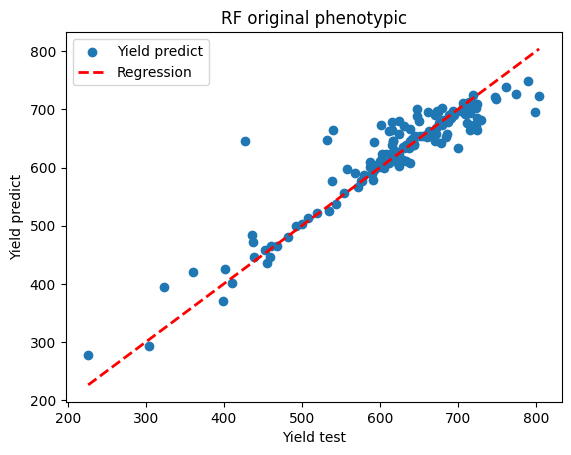

In [19]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean daily

In [20]:
file_csv = file_csv_original["phenotypic_weather_d"]
title_plot_true_predict = "RF Original phenotypic weather daily"

In [21]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [22]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [23]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.60724319354866
R2 -> 0.8683679652416361
MAPE -> 0.0386047838720562


{'d2_absolute_error_score': 0.6842162954938178,
 'd2_pinball_score': 0.6842162954938178,
 'd2_tweedie_score': 0.8683679652416361,
 'explained_variance_score': 0.8697634892186787,
 'max_error': 219.57578769999998,
 'mean_absolute_error': 22.034599361486446,
 'mean_absolute_percentage_error': 0.0386047838720562,
 'mean_gamma_deviance': 0.003821870368673421,
 'mean_poisson_deviance': 2.1410625947717885,
 'mean_squared_error': 1267.8757678445174,
 'mean_squared_log_error': 0.004029731089215683,
 'median_absolute_error': 12.542697050000072,
 'r2_score': 0.8683679652416361,
 'root_mean_squared_error': 35.60724319354866,
 'root_mean_squared_log_error': 0.06348016295832647}

Graficas

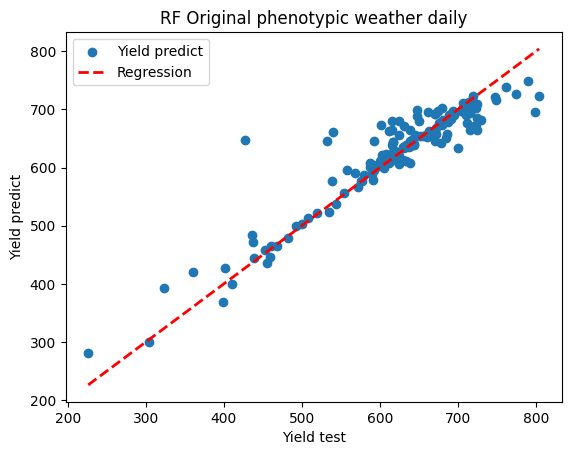

In [24]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean weekly

In [25]:
file_csv = file_csv_original["phenotypic_weather_w"]
title_plot_true_predict = "Heatmap RF phenotypic weather weekly"

In [26]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

/usr/local/lib/python3.12/site-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: [322]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Ejecutar la nueva ML

In [27]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [28]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.727294895101096
R2 -> 0.8674788602132151
MAPE -> 0.03810352670438258


{'d2_absolute_error_score': 0.6850783022318552,
 'd2_pinball_score': 0.6850783022318552,
 'd2_tweedie_score': 0.8674788602132151,
 'explained_variance_score': 0.8697097957817947,
 'max_error': 211.9322926000001,
 'mean_absolute_error': 21.974450681081102,
 'mean_absolute_percentage_error': 0.03810352670438258,
 'mean_gamma_deviance': 0.0035982609244871178,
 'mean_poisson_deviance': 2.101285233535312,
 'mean_squared_error': 1276.439600521517,
 'mean_squared_log_error': 0.003784253268779931,
 'median_absolute_error': 12.1227750500002,
 'r2_score': 0.8674788602132151,
 'root_mean_squared_error': 35.727294895101096,
 'root_mean_squared_log_error': 0.06151628458205137}

Graficas

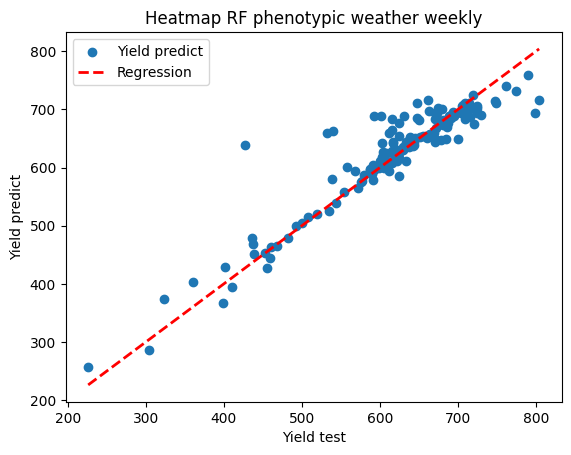

In [29]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean fortnightly

In [30]:
file_csv = file_csv_original["phenotypic_weather_f"]
title_plot_true_predict = "RF original phenotypic weather fortnightly"

In [31]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [32]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [33]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.70130663529879
R2 -> 0.8676715835206341
MAPE -> 0.038040177456780386


{'d2_absolute_error_score': 0.6854999226741043,
 'd2_pinball_score': 0.6854999226741043,
 'd2_tweedie_score': 0.8676715835206341,
 'explained_variance_score': 0.8699054125134567,
 'max_error': 213.21761060000006,
 'mean_absolute_error': 21.94503105810816,
 'mean_absolute_percentage_error': 0.038040177456780386,
 'mean_gamma_deviance': 0.003606059160158677,
 'mean_poisson_deviance': 2.1004798314117257,
 'mean_squared_error': 1274.5832954676293,
 'mean_squared_log_error': 0.0037953336666547493,
 'median_absolute_error': 12.083523799999739,
 'r2_score': 0.8676715835206341,
 'root_mean_squared_error': 35.70130663529879,
 'root_mean_squared_log_error': 0.061606279441748055}

Graficas

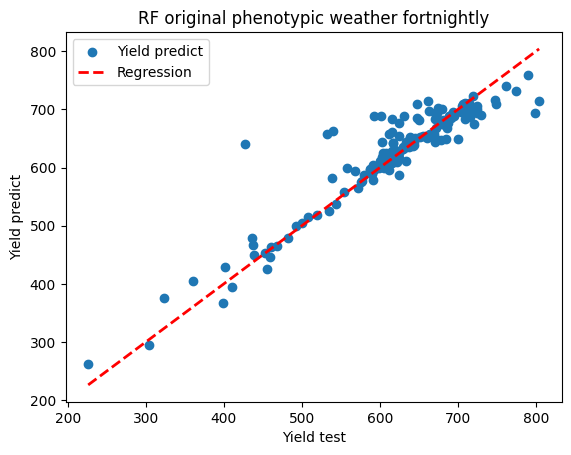

In [34]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean monthly

In [35]:
file_csv = file_csv_original["phenotypic_weather_m"]
title_plot_true_predict = "RF original phenotypic weather monthly"

In [36]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [37]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [38]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.840994490490175
R2 -> 0.866634039702426
MAPE -> 0.03821825471779673


{'d2_absolute_error_score': 0.6844688932657577,
 'd2_pinball_score': 0.6844688932657577,
 'd2_tweedie_score': 0.866634039702426,
 'explained_variance_score': 0.8688970747520302,
 'max_error': 213.44390420000002,
 'mean_absolute_error': 22.016973718918837,
 'mean_absolute_percentage_error': 0.03821825471779673,
 'mean_gamma_deviance': 0.00363973866517426,
 'mean_poisson_deviance': 2.117884920794772,
 'mean_squared_error': 1284.576886067347,
 'mean_squared_log_error': 0.003830581057914686,
 'median_absolute_error': 12.005018099999916,
 'r2_score': 0.866634039702426,
 'root_mean_squared_error': 35.840994490490175,
 'root_mean_squared_log_error': 0.06189168811653699}

Graficas

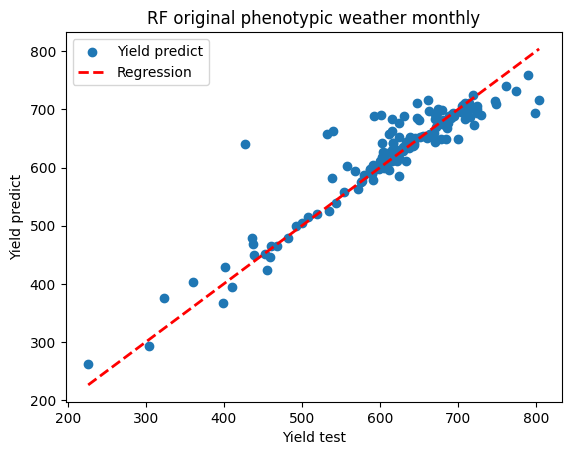

In [39]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

## Heatmap data

### Phenotypic

In [40]:
file_csv = file_csv_heatmap["phenotypic"]
title_plot_true_predict = "RF heatmap phenotypic"

In [41]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [42]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [43]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.78310882563658
R2 -> 0.8670644821744536
MAPE -> 0.03814452778540995


{'d2_absolute_error_score': 0.6848878079843523,
 'd2_pinball_score': 0.6848878079843523,
 'd2_tweedie_score': 0.8670644821744536,
 'explained_variance_score': 0.8693417406104389,
 'max_error': 214.19706140000005,
 'mean_absolute_error': 21.987742894594643,
 'mean_absolute_percentage_error': 0.03814452778540995,
 'mean_gamma_deviance': 0.003621299173263538,
 'mean_poisson_deviance': 2.1096430188606274,
 'mean_squared_error': 1280.4308772273507,
 'mean_squared_log_error': 0.0038123564364221808,
 'median_absolute_error': 11.92699900000008,
 'r2_score': 0.8670644821744536,
 'root_mean_squared_error': 35.78310882563658,
 'root_mean_squared_log_error': 0.06174428262132601}

Graficas

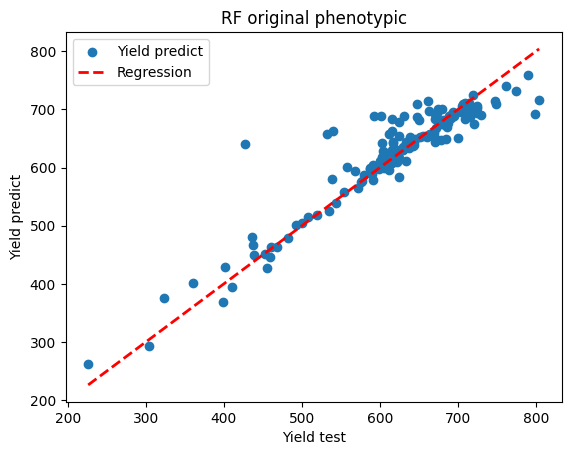

In [44]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean daily

In [45]:
file_csv = file_csv_heatmap["phenotypic_weather_d"]
title_plot_true_predict = "RF heatmap phenotypic weather daily"

In [46]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [47]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [48]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.721404753208716
R2 -> 0.8675225525204888
MAPE -> 0.03811296448365332


{'d2_absolute_error_score': 0.6850116138642954,
 'd2_pinball_score': 0.6850116138642954,
 'd2_tweedie_score': 0.8675225525204888,
 'explained_variance_score': 0.8697899734031134,
 'max_error': 213.88512089999995,
 'mean_absolute_error': 21.97910402905404,
 'mean_absolute_percentage_error': 0.03811296448365332,
 'mean_gamma_deviance': 0.003604620267094153,
 'mean_poisson_deviance': 2.101285498978764,
 'mean_squared_error': 1276.0187575425623,
 'mean_squared_log_error': 0.0037948759058132513,
 'median_absolute_error': 12.370568950000006,
 'r2_score': 0.8675225525204888,
 'root_mean_squared_error': 35.721404753208716,
 'root_mean_squared_log_error': 0.06160256411719606}

Graficas

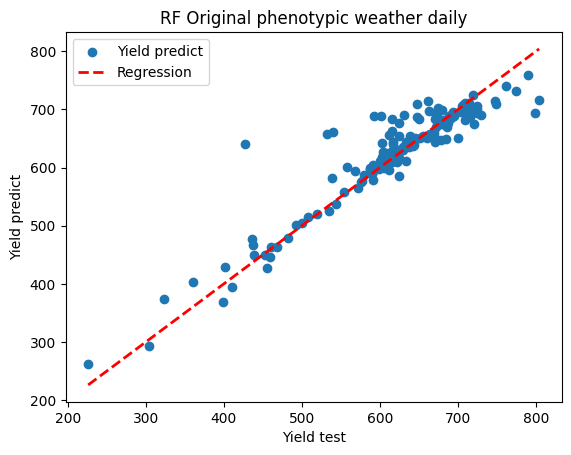

In [49]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean weekly

In [50]:
file_csv = file_csv_heatmap["phenotypic_weather_w"]
title_plot_true_predict = "RF Heatmap phenotypic weather weekly"

In [51]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [52]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [53]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.72176855781117
R2 -> 0.8675198540739483
MAPE -> 0.03818783473527023


{'d2_absolute_error_score': 0.6844524492806574,
 'd2_pinball_score': 0.6844524492806574,
 'd2_tweedie_score': 0.8675198540739483,
 'explained_variance_score': 0.8698663100523225,
 'max_error': 212.82980769999983,
 'mean_absolute_error': 22.01812113918917,
 'mean_absolute_percentage_error': 0.03818783473527023,
 'mean_gamma_deviance': 0.0036083346396782127,
 'mean_poisson_deviance': 2.1025330728194676,
 'mean_squared_error': 1276.0447488978266,
 'mean_squared_log_error': 0.003797124694110961,
 'median_absolute_error': 12.590765400000294,
 'r2_score': 0.8675198540739483,
 'root_mean_squared_error': 35.72176855781117,
 'root_mean_squared_log_error': 0.06162081380597761}

Graficas

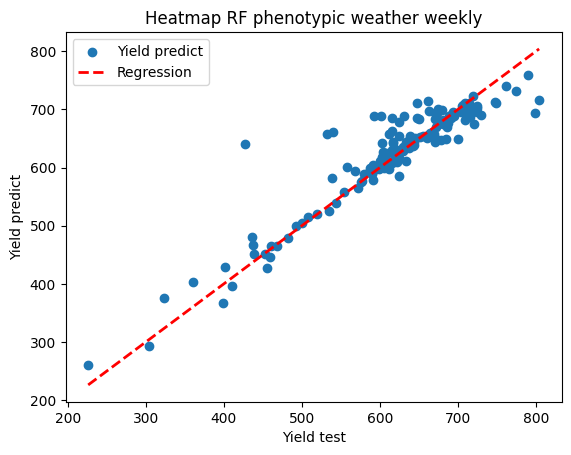

In [54]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean fortnightly

In [55]:
file_csv = file_csv_heatmap["phenotypic_weather_f"]
title_plot_true_predict = "RF heatmap phenotypic weather fortnightly"

In [56]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [57]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [58]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.83297115114551
R2 -> 0.8666937434356774
MAPE -> 0.03824562499605217


{'d2_absolute_error_score': 0.684110941854772,
 'd2_pinball_score': 0.684110941854772,
 'd2_tweedie_score': 0.8666937434356774,
 'explained_variance_score': 0.8689511598201378,
 'max_error': 214.62414409999997,
 'mean_absolute_error': 22.041950675675622,
 'mean_absolute_percentage_error': 0.03824562499605217,
 'mean_gamma_deviance': 0.0036300415607842355,
 'mean_poisson_deviance': 2.1158674527713064,
 'mean_squared_error': 1284.001821518826,
 'mean_squared_log_error': 0.0038218669638382845,
 'median_absolute_error': 12.16718025000057,
 'r2_score': 0.8666937434356774,
 'root_mean_squared_error': 35.83297115114551,
 'root_mean_squared_log_error': 0.061821250099284505}

Graficas

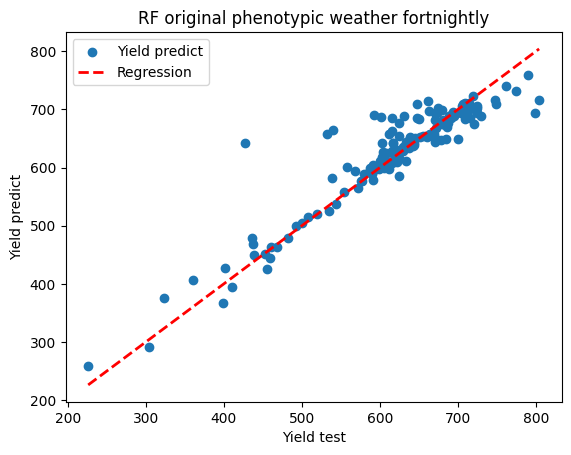

In [59]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean monthly

In [60]:
file_csv = file_csv_heatmap["phenotypic_weather_m"]
title_plot_true_predict = "RF heatmap phenotypic weather monthly"

In [61]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [62]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [63]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.81912897019868
R2 -> 0.866796715243931
MAPE -> 0.038080908061164626


{'d2_absolute_error_score': 0.6850209449419007,
 'd2_pinball_score': 0.6850209449419007,
 'd2_tweedie_score': 0.866796715243931,
 'explained_variance_score': 0.8691342004746274,
 'max_error': 214.69411709999963,
 'mean_absolute_error': 21.978452929729702,
 'mean_absolute_percentage_error': 0.038080908061164626,
 'mean_gamma_deviance': 0.0036069462400243604,
 'mean_poisson_deviance': 2.109897883415238,
 'mean_squared_error': 1283.0100001837268,
 'mean_squared_log_error': 0.00379825845525272,
 'median_absolute_error': 11.962992349999979,
 'r2_score': 0.866796715243931,
 'root_mean_squared_error': 35.81912897019868,
 'root_mean_squared_log_error': 0.06163001261765829}

Graficas

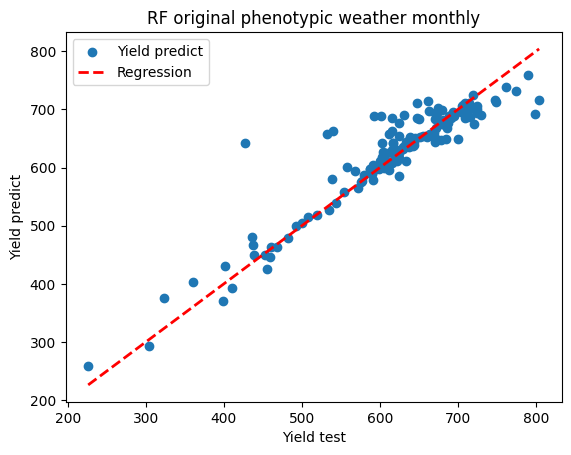

In [64]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

## PCA data

### Phenotypic

In [70]:
file_csv = file_csv_original["phenotypic"]
title_plot_true_predict = "RF PCA phenotypic"

In [72]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
    is_search_best_pca_component=True,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Evaluar PCA

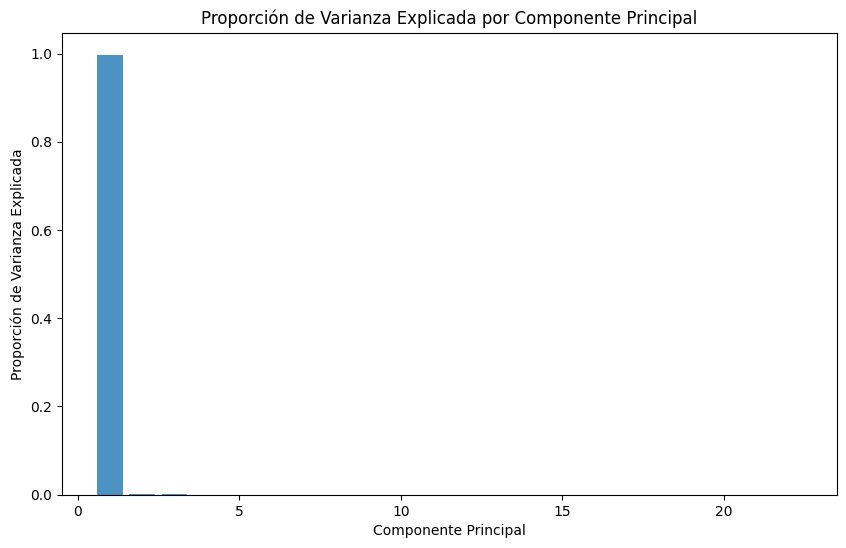

In [74]:
pca = preprocessing.get_pca()
pca.graph_scores()


Ejecutar la nueva ML

In [68]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [69]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 58.58726910208235
R2 -> 0.6436379873993064
MAPE -> 0.07618430412057121


{'d2_absolute_error_score': 0.37919176259497867,
 'd2_pinball_score': 0.37919176259497867,
 'd2_tweedie_score': 0.6436379873993064,
 'explained_variance_score': 0.6536960055891781,
 'max_error': 236.77499999999998,
 'mean_absolute_error': 43.318450560714105,
 'mean_absolute_percentage_error': 0.07618430412057121,
 'mean_gamma_deviance': 0.010187593977212469,
 'mean_poisson_deviance': 5.787415592010768,
 'mean_squared_error': 3432.4681008398134,
 'mean_squared_log_error': 0.010604924058429742,
 'median_absolute_error': 32.595379599999774,
 'r2_score': 0.6436379873993064,
 'root_mean_squared_error': 58.58726910208235,
 'root_mean_squared_log_error': 0.10298021197506704}

Graficas

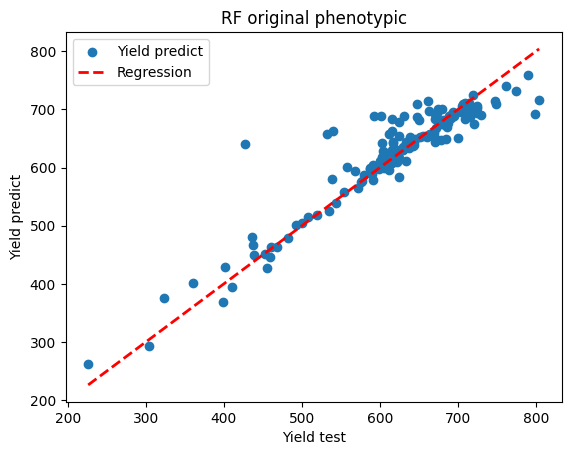

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean daily

In [ ]:
file_csv = file_csv_heatmap["phenotypic_weather_d"]
title_plot_true_predict = "RF Original phenotypic weather daily"

In [ ]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [ ]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [ ]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.721404753208716
R2 -> 0.8675225525204888
MAPE -> 0.03811296448365332


{'d2_absolute_error_score': 0.6850116138642954,
 'd2_pinball_score': 0.6850116138642954,
 'd2_tweedie_score': 0.8675225525204888,
 'explained_variance_score': 0.8697899734031134,
 'max_error': 213.88512089999995,
 'mean_absolute_error': 21.97910402905404,
 'mean_absolute_percentage_error': 0.03811296448365332,
 'mean_gamma_deviance': 0.003604620267094153,
 'mean_poisson_deviance': 2.101285498978764,
 'mean_squared_error': 1276.0187575425623,
 'mean_squared_log_error': 0.0037948759058132513,
 'median_absolute_error': 12.370568950000006,
 'r2_score': 0.8675225525204888,
 'root_mean_squared_error': 35.721404753208716,
 'root_mean_squared_log_error': 0.06160256411719606}

Graficas

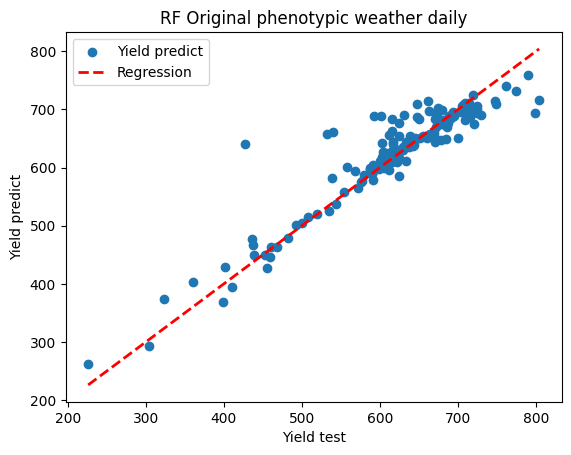

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean weekly

In [ ]:
file_csv = file_csv_heatmap["phenotypic_weather_w"]
title_plot_true_predict = "Heatmap RF phenotypic weather weekly"

In [ ]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [ ]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [ ]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.72176855781117
R2 -> 0.8675198540739483
MAPE -> 0.03818783473527023


{'d2_absolute_error_score': 0.6844524492806574,
 'd2_pinball_score': 0.6844524492806574,
 'd2_tweedie_score': 0.8675198540739483,
 'explained_variance_score': 0.8698663100523225,
 'max_error': 212.82980769999983,
 'mean_absolute_error': 22.01812113918917,
 'mean_absolute_percentage_error': 0.03818783473527023,
 'mean_gamma_deviance': 0.0036083346396782127,
 'mean_poisson_deviance': 2.1025330728194676,
 'mean_squared_error': 1276.0447488978266,
 'mean_squared_log_error': 0.003797124694110961,
 'median_absolute_error': 12.590765400000294,
 'r2_score': 0.8675198540739483,
 'root_mean_squared_error': 35.72176855781117,
 'root_mean_squared_log_error': 0.06162081380597761}

Graficas

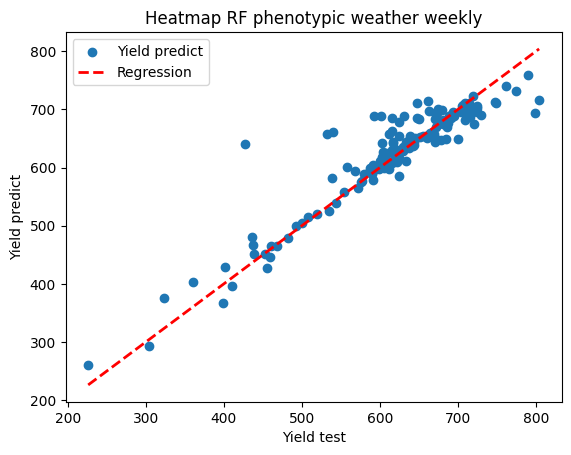

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean fortnightly

In [ ]:
file_csv = file_csv_heatmap["phenotypic_weather_f"]
title_plot_true_predict = "RF original phenotypic weather fortnightly"

In [ ]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [ ]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [ ]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.83297115114551
R2 -> 0.8666937434356774
MAPE -> 0.03824562499605217


{'d2_absolute_error_score': 0.684110941854772,
 'd2_pinball_score': 0.684110941854772,
 'd2_tweedie_score': 0.8666937434356774,
 'explained_variance_score': 0.8689511598201378,
 'max_error': 214.62414409999997,
 'mean_absolute_error': 22.041950675675622,
 'mean_absolute_percentage_error': 0.03824562499605217,
 'mean_gamma_deviance': 0.0036300415607842355,
 'mean_poisson_deviance': 2.1158674527713064,
 'mean_squared_error': 1284.001821518826,
 'mean_squared_log_error': 0.0038218669638382845,
 'median_absolute_error': 12.16718025000057,
 'r2_score': 0.8666937434356774,
 'root_mean_squared_error': 35.83297115114551,
 'root_mean_squared_log_error': 0.061821250099284505}

Graficas

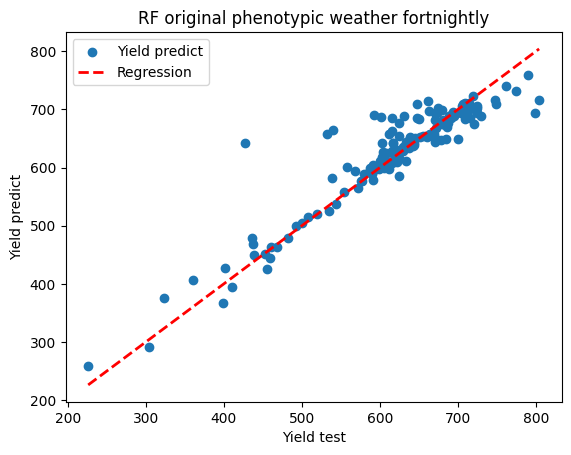

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean monthly

In [ ]:
file_csv = file_csv_heatmap["phenotypic_weather_m"]
title_plot_true_predict = "RF original phenotypic weather monthly"

In [ ]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [ ]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [ ]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.81912897019868
R2 -> 0.866796715243931
MAPE -> 0.038080908061164626


{'d2_absolute_error_score': 0.6850209449419007,
 'd2_pinball_score': 0.6850209449419007,
 'd2_tweedie_score': 0.866796715243931,
 'explained_variance_score': 0.8691342004746274,
 'max_error': 214.69411709999963,
 'mean_absolute_error': 21.978452929729702,
 'mean_absolute_percentage_error': 0.038080908061164626,
 'mean_gamma_deviance': 0.0036069462400243604,
 'mean_poisson_deviance': 2.109897883415238,
 'mean_squared_error': 1283.0100001837268,
 'mean_squared_log_error': 0.00379825845525272,
 'median_absolute_error': 11.962992349999979,
 'r2_score': 0.866796715243931,
 'root_mean_squared_error': 35.81912897019868,
 'root_mean_squared_log_error': 0.06163001261765829}

Graficas

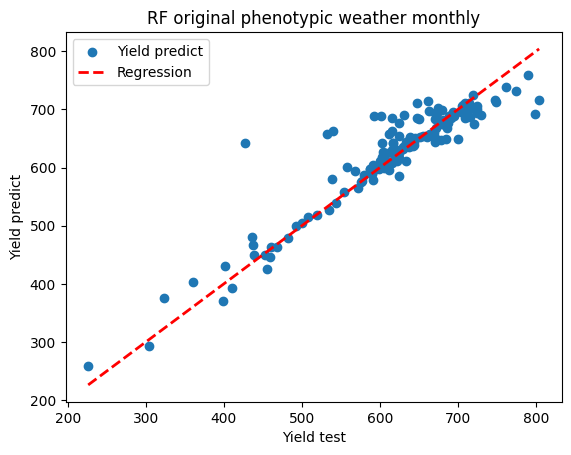

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)